# Task 3.6

This notebook answers Task 3.6. It solves the full problem from Task 3.5 for every beer color in Table 1.

In [15]:
from brew_utils import *
from scipy.optimize import linprog
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3.6 Full Problem for All Beer Colors

We solve the same full problem as in Task 3.5:
- 5000 litres of beer
- minimum average quality 3 for malt sources, hops, and yeast

The only change is the required beer color. For each color class from Table 1, we use its EBC interval and solve the model.

In [16]:
barley_cost = barley["cost"].to_numpy(dtype=float)
barley_ebc = barley["EBC"].to_numpy(dtype=float)
barley_q = barley["quality"].to_numpy(dtype=float)

malt_cost = malts["cost"].to_numpy(dtype=float)
malt_ebc = malts["EBC"].to_numpy(dtype=float)
malt_q = malts["quality"].to_numpy(dtype=float)

extract_cost = maltextracts["cost"].to_numpy(dtype=float)
extract_ebc = maltextracts["EBC"].to_numpy(dtype=float)
extract_q = maltextracts["quality"].to_numpy(dtype=float)

hop_cost = hops["cost"].to_numpy(dtype=float)
hop_q = hops["quality"].to_numpy(dtype=float)

yeast_cost = yeasts["cost"].to_numpy(dtype=float)
yeast_q = yeasts["quality"].to_numpy(dtype=float)

F_malt = float(maltprocess.loc[0, "fixedcost"])
v_malt = float(maltprocess.loc[0, "variablecost"])
F_mash = float(mashingprocess.loc[0, "fixedcost"])
v_mash = float(mashingprocess.loc[0, "variablecost"])

nB = len(barley)
nM = len(malts)
nE = len(maltextracts)
nH = len(hops)
nY = len(yeasts)

iB0 = 0
iM0 = iB0 + nB
iE0 = iM0 + nM
iH0 = iE0 + nE
iY0 = iH0 + nH
iZm = iY0 + nY
iZs = iZm + 1
nvars = iZs + 1

def slice_B():
    return slice(iB0, iB0 + nB)

def slice_M():
    return slice(iM0, iM0 + nM)

def slice_E():
    return slice(iE0, iE0 + nE)

def slice_H():
    return slice(iH0, iH0 + nH)

def slice_Y():
    return slice(iY0, iY0 + nY)

## 3.6 Model and Solver

This is the same full MILP as in Task 3.5. It includes:
- the malt-extract-equivalent balance
- exact hop and yeast quantities
- lower and upper EBC bounds
- minimum quality constraints
- binary process variables for malting and mashing

The original MILP is solved by brute force over the valid process choices.

In [17]:
def build_lp_model(V_beer, EBC_min, EBC_max, Q_malt, Q_hop, Q_yeast, z_fix=None):
    m_tot = malt_extract_eq_needed_for_beer(V_beer)
    H_tot = hops_needed_for_beer(V_beer)
    Y_tot = yeast_needed_for_beer(V_beer)
    gamma = (SG - 1.0) / 0.0344

    M_B = m_tot / BARLEY_TO_MALTEXTRACT_EQ
    M_M = m_tot / MALT_TO_MALTEXTRACT_EQ

    c = np.zeros(nvars)
    c[slice_B()] = barley_cost + v_malt + v_mash * BARLEY_TO_MALT
    c[slice_M()] = malt_cost + v_mash
    c[slice_E()] = extract_cost
    c[slice_H()] = hop_cost
    c[slice_Y()] = yeast_cost
    c[iZm] = F_malt
    c[iZs] = F_mash

    A_eq = []
    b_eq = []

    row = np.zeros(nvars)
    row[slice_B()] = BARLEY_TO_MALTEXTRACT_EQ
    row[slice_M()] = MALT_TO_MALTEXTRACT_EQ
    row[slice_E()] = 1.0
    A_eq.append(row)
    b_eq.append(m_tot)

    row = np.zeros(nvars)
    row[slice_H()] = 1.0
    A_eq.append(row)
    b_eq.append(H_tot)

    row = np.zeros(nvars)
    row[slice_Y()] = 1.0
    A_eq.append(row)
    b_eq.append(Y_tot)

    A_ub = []
    b_ub = []

    if np.isfinite(EBC_max):
        row = np.zeros(nvars)
        row[slice_B()] = gamma * BARLEY_TO_MALTEXTRACT_EQ * barley_ebc
        row[slice_M()] = gamma * MALT_TO_MALTEXTRACT_EQ * malt_ebc
        row[slice_E()] = gamma * extract_ebc
        A_ub.append(row)
        b_ub.append(EBC_max * m_tot)

    row = np.zeros(nvars)
    row[slice_B()] = -gamma * BARLEY_TO_MALTEXTRACT_EQ * barley_ebc
    row[slice_M()] = -gamma * MALT_TO_MALTEXTRACT_EQ * malt_ebc
    row[slice_E()] = -gamma * extract_ebc
    A_ub.append(row)
    b_ub.append(-EBC_min * m_tot)

    row = np.zeros(nvars)
    row[slice_B()] = -BARLEY_TO_MALTEXTRACT_EQ * barley_q
    row[slice_M()] = -MALT_TO_MALTEXTRACT_EQ * malt_q
    row[slice_E()] = -extract_q
    A_ub.append(row)
    b_ub.append(-Q_malt * m_tot)

    row = np.zeros(nvars)
    row[slice_H()] = -hop_q
    A_ub.append(row)
    b_ub.append(-Q_hop * H_tot)

    row = np.zeros(nvars)
    row[slice_Y()] = -yeast_q
    A_ub.append(row)
    b_ub.append(-Q_yeast * Y_tot)

    row = np.zeros(nvars)
    row[slice_B()] = 1.0
    row[iZm] = -M_B
    A_ub.append(row)
    b_ub.append(0.0)

    row = np.zeros(nvars)
    row[slice_B()] = BARLEY_TO_MALT
    row[slice_M()] = 1.0
    row[iZs] = -M_M
    A_ub.append(row)
    b_ub.append(0.0)

    row = np.zeros(nvars)
    row[iZm] = 1.0
    row[iZs] = -1.0
    A_ub.append(row)
    b_ub.append(0.0)

    bounds = [(0, None)] * nvars
    if z_fix is None:
        bounds[iZm] = (0, 1)
        bounds[iZs] = (0, 1)
    else:
        bounds[iZm] = (z_fix[0], z_fix[0])
        bounds[iZs] = (z_fix[1], z_fix[1])

    return {
        "c": c,
        "A_eq": np.array(A_eq, dtype=float),
        "b_eq": np.array(b_eq, dtype=float),
        "A_ub": np.array(A_ub, dtype=float),
        "b_ub": np.array(b_ub, dtype=float),
        "bounds": bounds,
        "m_tot": m_tot,
        "H_tot": H_tot,
        "Y_tot": Y_tot,
    }

def solve_with_fixed_processes(V_beer, EBC_min, EBC_max, Q_malt, Q_hop, Q_yeast, z_malt, z_mash):
    model = build_lp_model(V_beer, EBC_min, EBC_max, Q_malt, Q_hop, Q_yeast, z_fix=(z_malt, z_mash))
    res = linprog(
        c=model["c"],
        A_ub=model["A_ub"],
        b_ub=model["b_ub"],
        A_eq=model["A_eq"],
        b_eq=model["b_eq"],
        bounds=model["bounds"],
        method="highs",
    )
    return model, res

def solve_bruteforce(V_beer, EBC_min, EBC_max, Q_malt, Q_hop, Q_yeast):
    candidates = [(0, 0), (0, 1), (1, 1)]
    best = None
    all_results = []

    for z_fix in candidates:
        model, res = solve_with_fixed_processes(V_beer, EBC_min, EBC_max, Q_malt, Q_hop, Q_yeast, *z_fix)
        info = {
            "z_fix": z_fix,
            "success": res.success,
            "cost": res.fun if res.success else np.nan,
            "result": res,
            "model": model,
        }
        all_results.append(info)
        if res.success and (best is None or res.fun < best["cost"]):
            best = info

    return best, all_results

## 3.6.1 Solve the Full Problem for Every Color

We solve the model for each color class in `EBC_RANGES` and store the resulting total cost, process choice, and feasibility status.

In [18]:
def summarize_solution(model, res):
    x = res.x
    b = x[slice_B()]
    m = x[slice_M()]
    e = x[slice_E()]
    h = x[slice_H()]
    y = x[slice_Y()]

    m_tot = model["m_tot"]
    H_tot = model["H_tot"]
    Y_tot = model["Y_tot"]
    gamma = (SG - 1.0) / 0.0344

    ebc_value = gamma * (
        BARLEY_TO_MALTEXTRACT_EQ * np.sum(barley_ebc * b)
        + MALT_TO_MALTEXTRACT_EQ * np.sum(malt_ebc * m)
        + np.sum(extract_ebc * e)
    ) / m_tot if m_tot > 0 else 0.0

    q_malt_value = (
        BARLEY_TO_MALTEXTRACT_EQ * np.sum(barley_q * b)
        + MALT_TO_MALTEXTRACT_EQ * np.sum(malt_q * m)
        + np.sum(extract_q * e)
    ) / m_tot if m_tot > 0 else 0.0
    q_hop_value = np.sum(hop_q * h) / H_tot if H_tot > 0 else 0.0
    q_yeast_value = np.sum(yeast_q * y) / Y_tot if Y_tot > 0 else 0.0

    return {
        "cost": res.fun,
        "EBC": ebc_value,
        "Q_malt": q_malt_value,
        "Q_hop": q_hop_value,
        "Q_yeast": q_yeast_value,
        "z_malt": x[iZm],
        "z_mash": x[iZs],
    }

V_beer = 5000
Q_malt = 3
Q_hop = 3
Q_yeast = 3

rows = []
detailed_results = {}

for color_name, (EBC_min, EBC_max) in EBC_RANGES.items():
    best_solution, all_results = solve_bruteforce(V_beer, EBC_min, EBC_max, Q_malt, Q_hop, Q_yeast)

    if best_solution is None:
        rows.append({
            "color": color_name,
            "EBC_min": EBC_min,
            "EBC_max": EBC_max,
            "feasible": False,
            "cost": np.nan,
            "z_malt": np.nan,
            "z_mash": np.nan,
        })
        detailed_results[color_name] = None
    else:
        summary = summarize_solution(best_solution["model"], best_solution["result"])
        rows.append({
            "color": color_name,
            "EBC_min": EBC_min,
            "EBC_max": EBC_max,
            "feasible": True,
            "cost": summary["cost"],
            "EBC": summary["EBC"],
            "Q_malt": summary["Q_malt"],
            "Q_hop": summary["Q_hop"],
            "Q_yeast": summary["Q_yeast"],
            "z_malt": summary["z_malt"],
            "z_mash": summary["z_mash"],
        })
        detailed_results[color_name] = best_solution

results_df = pd.DataFrame(rows)
results_df

,color,EBC_min,EBC_max,feasible,cost,z_malt,z_mash,EBC,Q_malt,Q_hop,Q_yeast
0,light blond,6.000000,8.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,blond,9.000000,12.0,True,4919.601053,-0.0,1.0,12.000000,3.0,3.0,3.0
2,gold,13.000000,19.0,True,4883.000000,-0.0,1.0,14.534884,3.0,3.0,3.0
3,amber,20.000000,29.0,True,4891.923363,0.0,1.0,20.000000,3.0,3.0,3.0
4,copper,30.000000,45.0,True,4908.251220,0.0,1.0,30.000000,3.0,3.0,3.0
5,brown,46.000000,75.0,True,4934.375789,0.0,1.0,46.000000,3.0,3.0,3.0
6,dark brown,76.000000,120.0,True,4983.359358,0.0,1.0,76.000000,3.0,3.0,3.0
7,black,120.000001,inf,True,5061.830290,0.0,1.0,120.000001,3.0,3.0,3.0


## 3.6.1 Visualize Cost as a Function of Beer Color

We plot the minimum total cost for each color class. For the x-axis, we use the midpoint of the EBC interval, except for black where we place the point at 130 for visualization.

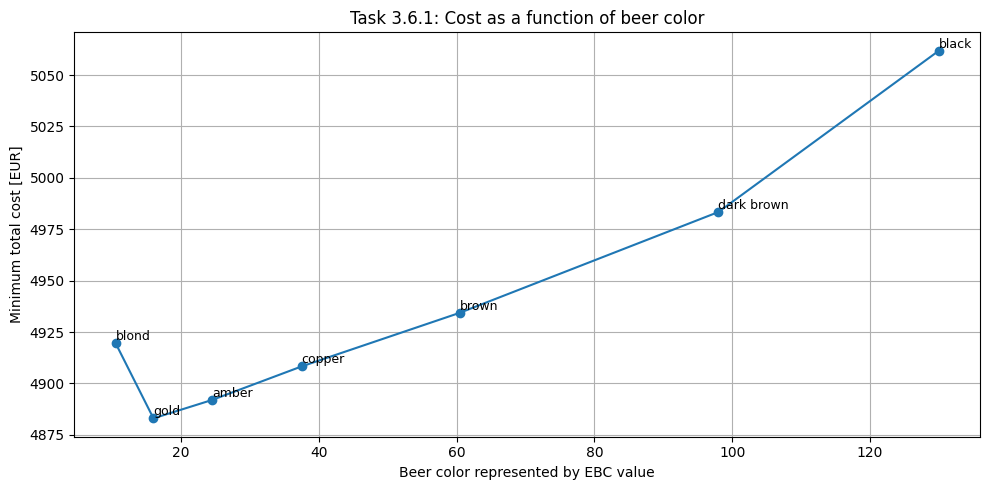

In [19]:
plot_df = results_df.copy()
plot_df["plot_ebc"] = plot_df.apply(
    lambda row: 130 if np.isinf(row["EBC_max"]) else 0.5 * (row["EBC_min"] + row["EBC_max"]),
    axis=1,
)

feasible_df = plot_df[plot_df["feasible"]].copy()

plt.figure(figsize=(10, 5))
plt.plot(feasible_df["plot_ebc"], feasible_df["cost"], marker="o")
for _, row in feasible_df.iterrows():
    plt.text(row["plot_ebc"], row["cost"], row["color"], fontsize=9, ha="left", va="bottom")
plt.xlabel("Beer color represented by EBC value")
plt.ylabel("Minimum total cost [EUR]")
plt.title("Task 3.6.1: Cost as a function of beer color")
plt.grid(True)
plt.tight_layout()
plt.show()

## 3.6.2 Explain Which Colors Are Cheapest or Most Expensive

The table below helps explain the cost pattern. In general, certain color ranges are cheaper when they can be achieved with inexpensive malt sources that also satisfy the quality constraints. Other color ranges may require more expensive combinations or the use of additional process steps.

In [20]:
results_df.sort_values("cost")

,color,EBC_min,EBC_max,feasible,cost,z_malt,z_mash,EBC,Q_malt,Q_hop,Q_yeast
2,gold,13.000000,19.0,True,4883.000000,-0.0,1.0,14.534884,3.0,3.0,3.0
3,amber,20.000000,29.0,True,4891.923363,0.0,1.0,20.000000,3.0,3.0,3.0
4,copper,30.000000,45.0,True,4908.251220,0.0,1.0,30.000000,3.0,3.0,3.0
1,blond,9.000000,12.0,True,4919.601053,-0.0,1.0,12.000000,3.0,3.0,3.0
5,brown,46.000000,75.0,True,4934.375789,0.0,1.0,46.000000,3.0,3.0,3.0
6,dark brown,76.000000,120.0,True,4983.359358,0.0,1.0,76.000000,3.0,3.0,3.0
7,black,120.000001,inf,True,5061.830290,0.0,1.0,120.000001,3.0,3.0,3.0
0,light blond,6.000000,8.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.6.3 Are All Colors Reachable?

This final part checks which color classes are feasible under the full set of constraints. If a color class is infeasible, it means that no ingredient combination satisfies the volume, color, process, and quality requirements at the same time.

In [21]:
results_df[["color", "feasible", "cost", "EBC_min", "EBC_max"]]

,color,feasible,cost,EBC_min,EBC_max
0,light blond,False,NaN,6.000000,8.0
1,blond,True,4919.601053,9.000000,12.0
2,gold,True,4883.000000,13.000000,19.0
3,amber,True,4891.923363,20.000000,29.0
4,copper,True,4908.251220,30.000000,45.0
5,brown,True,4934.375789,46.000000,75.0
6,dark brown,True,4983.359358,76.000000,120.0
7,black,True,5061.830290,120.000001,inf


<!-- REPORT_TABLE_OUTPUTS_SYNC -->
## Report table outputs

The following tables correspond to the tables used in the LaTeX report for Task 3.6.

In [22]:
# REPORT_TABLE_OUTPUTS_SYNC
print("Table 9.1: Task 6 Results for All Beer Colours")
task36_results_table = results_df.copy()
task36_results_table["EBC range"] = task36_results_table.apply(
    lambda r: ">120" if r["color"] == "black" else f"{r['EBC_min']:.0f}--{r['EBC_max']:.0f}",
    axis=1,
)
task36_results_table["Feasible"] = task36_results_table["feasible"].map({True: "yes", False: "no"})
task36_results_table = task36_results_table[["color", "EBC range", "Feasible", "cost", "EBC"]].rename(
    columns={"color": "Colour", "cost": "Cost", "EBC": "Achieved EBC"}
).round({"Cost": 3, "Achieved EBC": 6})
display(task36_results_table)

def report_nonzero_ingredients(x, tol=1e-7):
    groups = [
        ("Barley", list(barley["name"]), x[slice_B()]),
        ("Malt", list(malts["name"]), x[slice_M()]),
        ("Malt extract", list(maltextracts["name"]), x[slice_E()]),
        ("Hops", list(hops["name"]), x[slice_H()]),
        ("Yeast", list(yeasts["name"]), x[slice_Y()]),
    ]
    rows = []
    for group, names, values in groups:
        for name, value in zip(names, values):
            if abs(value) > tol:
                rows.append((group, name, value))
    return rows

def ingredient_mix_text(x):
    return "; ".join(f"{name} {value:.3f} kg" for _, name, value in report_nonzero_ingredients(x))

summary_rows = []
ingredient_rows = []
for color_name, best in detailed_results.items():
    if best is None:
        continue
    summary = summarize_solution(best["model"], best["result"])
    summary_rows.append({
        "Colour": color_name,
        "Process": f"({int(round(summary['z_malt']))},{int(round(summary['z_mash']))})",
        "Cost": summary["cost"],
        "EBC": summary["EBC"],
        "$Q_S$": summary["Q_malt"],
        "$Q_H$": summary["Q_hop"],
        "$Q_Y$": summary["Q_yeast"],
    })
    ingredient_rows.append({"Colour": color_name, "Non-zero ingredients": ingredient_mix_text(best["result"].x)})

print("Table 9.2: Task 6 Solution Summary for Feasible Beer Colours")
task36_solution_summary_table = pd.DataFrame(summary_rows)
task36_solution_summary_table["Cost"] = task36_solution_summary_table["Cost"].map(lambda x: f"{x:.3f}")
task36_solution_summary_table["EBC"] = task36_solution_summary_table.apply(
    lambda r: f"{r['EBC']:.6f}" if r["Colour"] == "black" else f"{r['EBC']:.3f}",
    axis=1,
)
for col in ["$Q_S$", "$Q_H$", "$Q_Y$"]:
    task36_solution_summary_table[col] = task36_solution_summary_table[col].map(lambda x: f"{x:.3f}")
display(task36_solution_summary_table)

print("Table 9.3: Task 6 Non-Zero Ingredient Mixes for Feasible Colours")
task36_nonzero_ingredients_table = pd.DataFrame(ingredient_rows)
display(task36_nonzero_ingredients_table)


Table 9.1: Task 6 Results for All Beer Colours


,Colour,EBC range,Feasible,Cost,Achieved EBC
0,light blond,6--8,no,NaN,NaN
1,blond,9--12,yes,4919.601,12.000000
2,gold,13--19,yes,4883.000,14.534884
3,amber,20--29,yes,4891.923,20.000000
4,copper,30--45,yes,4908.251,30.000000
5,brown,46--75,yes,4934.376,46.000000
6,dark brown,76--120,yes,4983.359,76.000000
7,black,>120,yes,5061.830,120.000001


Table 9.2: Task 6 Solution Summary for Feasible Beer Colours


,Colour,Process,Cost,EBC,$Q_S$,$Q_H$,$Q_Y$
0,blond,"(0,1)",4919.601,12.000,3.000,3.000,3.000
1,gold,"(0,1)",4883.000,14.535,3.000,3.000,3.000
2,amber,"(0,1)",4891.923,20.000,3.000,3.000,3.000
3,copper,"(0,1)",4908.251,30.000,3.000,3.000,3.000
4,brown,"(0,1)",4934.376,46.000,3.000,3.000,3.000
5,dark brown,"(0,1)",4983.359,76.000,3.000,3.000,3.000
6,black,"(0,1)",5061.830,120.000001,3.000,3.000,3.000


Table 9.3: Task 6 Non-Zero Ingredient Mixes for Feasible Colours


,Colour,Non-zero ingredients
0,blond,malt03 454.842 kg; malt04 332.737 kg; malt11 1...
1,gold,malt03 953.947 kg; hop07 3.421 kg; hop10 3.421...
2,amber,malt03 901.457 kg; malt06 17.497 kg; malt12 34...
3,copper,malt03 805.411 kg; malt06 49.512 kg; malt12 99...
4,brown,malt03 651.737 kg; malt06 100.737 kg; malt12 2...
5,dark brown,malt03 363.598 kg; malt06 196.783 kg; malt12 3...
6,black,malt01 72.431 kg; malt06 293.839 kg; malt12 58...
